In [1]:
import os, re, json, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tf.random.set_seed(42)
np.random.seed(42)

os.makedirs('results', exist_ok=True)
print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")

TensorFlow  : 2.20.0
NumPy       : 2.0.2
Pandas      : 2.2.2


In [2]:
#Tassk 1
df = pd.read_csv('customer_support_text_classification.csv')

print(f"{'─'*55}")
print(f"  Records           : {len(df)}")
print(f"  Columns           : {list(df.columns)}")
print(f"{'─'*55}")
df.head(5)

───────────────────────────────────────────────────────
  Records           : 1500
  Columns           : ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']
───────────────────────────────────────────────────────


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [3]:
#Target labels
print("Target Classes:", df['sentiment_label'].unique())
vc  = df['sentiment_label'].value_counts()
vcp = df['sentiment_label'].value_counts(normalize=True) * 100
for cls in vc.index:
    print(f"  {cls:>10} : {vc[cls]:>4}  ({vcp[cls]:.1f}%)")
print(f"  → Perfectly balanced dataset (≈33% each class)")


Target Classes: ['neutral' 'positive' 'negative']
     neutral :  524  (34.9%)
    negative :  497  (33.1%)
    positive :  479  (31.9%)
  → Perfectly balanced dataset (≈33% each class)


In [4]:
#Sample messages
print("Sample messages per class:")
for cls in ['negative', 'neutral', 'positive']:
    sample = df[df['sentiment_label'] == cls]['customer_message'].values[0]
    print(f"  [{cls.upper():>8}]: {sample}")

Sample messages per class:
  [NEGATIVE]: My refund is still pending and this experience is frustrating. My ticket number is 33927.
  [ NEUTRAL]: I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
  [POSITIVE]: The refund process was fast and convenient. I appreciate the quick response.


In [5]:
#Text length analysis
print("Word count statistics:")
print(df['word_count'].describe().round(2).to_string())
print(f"\n  Average word count : {df['word_count'].mean():.2f}")
print(f"  Min / Max          : {df['word_count'].min()} / {df['word_count'].max()}")
print(f"  Channel breakdown  : {df['channel'].value_counts().to_dict()}")
print(f"  Urgent flag        : {df['urgent_flag'].value_counts().to_dict()}")

Word count statistics:
count    1500.00
mean       12.72
std         3.69
min         7.00
25%        10.00
50%        12.00
75%        15.00
max        26.00

  Average word count : 12.72
  Min / Max          : 7 / 26
  Channel breakdown  : {'email': 326, 'social': 314, 'phone': 296, 'chat': 290, 'app': 274}
  Urgent flag        : {0: 1100, 1: 400}


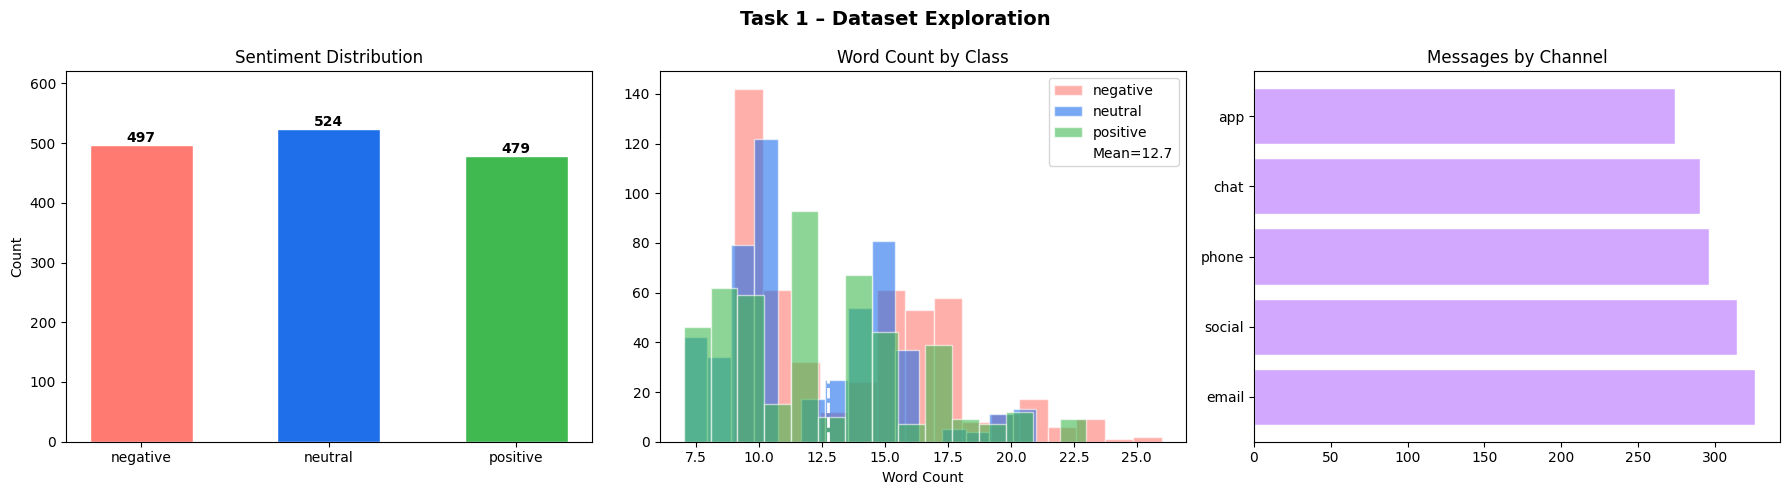

In [6]:
#Visualise
CLASSES = ['negative', 'neutral', 'positive']
COLORS  = ['#FF7B72', '#1F6FEB', '#3FB950']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Task 1 – Dataset Exploration', fontsize=14, fontweight='bold')

# Class distribution
counts = [vc['negative'], vc['neutral'], vc['positive']]
bars = axes[0].bar(CLASSES, counts, color=COLORS, edgecolor='white', width=0.55)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 str(val), ha='center', fontweight='bold')
axes[0].set_title('Sentiment Distribution'); axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 620)

# Word count by class
for cls, color in zip(CLASSES, COLORS):
    axes[1].hist(df[df['sentiment_label']==cls]['word_count'],
                 bins=15, alpha=0.6, color=color, label=cls, edgecolor='white')
axes[1].axvline(df['word_count'].mean(), color='white', linestyle='--', lw=2, label=f'Mean={df["word_count"].mean():.1f}')
axes[1].set_title('Word Count by Class'); axes[1].set_xlabel('Word Count')
axes[1].legend()

# Channel distribution
ch_counts = df['channel'].value_counts()
axes[2].barh(ch_counts.index, ch_counts.values, color='#D2A8FF', edgecolor='white')
axes[2].set_title('Messages by Channel')

plt.tight_layout()
plt.savefig('results/task1_exploration.png', dpi=130, bbox_inches='tight')
plt.show()


In [7]:
#Task2
#Stopword list
STOPWORDS = {
    'i','me','my','we','our','you','your','he','him','his','she','her',
    'it','its','they','them','their','what','which','who','this','that',
    'these','those','am','is','are','was','were','be','been','being',
    'have','has','had','do','does','did','a','an','the','and','but',
    'if','or','as','at','by','for','with','about','into','through',
    'to','from','up','in','out','on','off','over','not','no','nor',
    'so','can','will','just','should','now','ticket','number','my',
    'please','respond','soon','possible'
}

def preprocess(text: str) -> str:
    """Full text preprocessing pipeline."""
    # Step 1: Lowercase
    text = str(text).lower()
    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Step 3: Remove standalone numbers (ticket numbers etc.)
    text = re.sub(r'\b\d+\b', '', text)
    # Step 4: Remove special characters (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # Step 5: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Step 6: Tokenise and remove stopwords (min 3 chars)
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) >= 3]
    return ' '.join(tokens)

df['clean_text']   = df['customer_message'].apply(preprocess)
df['token_count']  = df['clean_text'].apply(lambda x: len(x.split()))

print("Preprocessing complete!")
print(f"  Avg tokens BEFORE cleaning : {df['word_count'].mean():.1f}")
print(f"  Avg tokens AFTER  cleaning : {df['token_count'].mean():.1f}")
print(f"  Reduction: {(1 - df['token_count'].mean()/df['word_count'].mean())*100:.1f}%")

Preprocessing complete!
  Avg tokens BEFORE cleaning : 12.7
  Avg tokens AFTER  cleaning : 5.5
  Reduction: 56.5%


In [8]:
#Before and After examples
print("Before → After Preprocessing (3 examples):\n")
for i, row in df.sample(3, random_state=7).iterrows():
    print(f"  BEFORE  [{row['sentiment_label'].upper():>8}]: {row['customer_message']}")
    print(f"  AFTER   [{row['sentiment_label'].upper():>8}]: {row['clean_text']}")
    print()

Before → After Preprocessing (3 examples):

  BEFORE  [ NEUTRAL]: Can you share the status of my insurance policy request? Please respond as soon as possible.
  AFTER   [ NEUTRAL]: share status insurance policy request

  BEFORE  [POSITIVE]: I am satisfied with the plan and would recommend it to others.
  AFTER   [POSITIVE]: satisfied plan would recommend others

  BEFORE  [NEGATIVE]: I want to cancel because the service quality is poor and unreliable. My ticket number is 18716.
  AFTER   [NEGATIVE]: want cancel because service quality poor unreliable



In [9]:
#Train/Test split
le = LabelEncoder()
y  = le.fit_transform(df['sentiment_label'])   # neg=0, neu=1, pos=2

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['clean_text'], y, test_size=0.2, random_state=42, stratify=y)

print(f"Train : {len(X_train_raw)} samples")
print(f"Test  : {len(X_test_raw)} samples")
print(f"Classes (encoded): {dict(zip(le.classes_, le.transform(le.classes_)))}")

Train : 1200 samples
Test  : 300 samples
Classes (encoded): {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [10]:
#Task 3
#Bag of Words
bow_vec      = CountVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_bow  = bow_vec.fit_transform(X_train_raw)
X_test_bow   = bow_vec.transform(X_test_raw)

print("=== Bag of Words ===")
print(f"  Matrix shape (train) : {X_train_bow.shape}")
print(f"  Matrix shape (test)  : {X_test_bow.shape}")
print(f"  Vocabulary size      : {len(bow_vec.vocabulary_)}")
print(f"  Matrix sparsity      : {(1 - X_train_bow.nnz / (X_train_bow.shape[0]*X_train_bow.shape[1]))*100:.1f}%")

# Top 15 unigrams
top_bow = sorted(zip(bow_vec.get_feature_names_out(),
                     np.asarray(X_train_bow.sum(axis=0)).flatten()),
                 key=lambda x: -x[1])
top_unigrams = [(t,c) for t,c in top_bow if ' ' not in t][:15]
print(f"\n  Top 15 tokens: {[t for t,_ in top_unigrams]}")

=== Bag of Words ===
  Matrix shape (train) : (1200, 365)
  Matrix shape (test)  : (300, 365)
  Vocabulary size      : 365
  Matrix sparsity      : 97.2%

  Top 15 tokens: ['service', 'quality', 'response', 'product', 'support', 'team', 'appreciate', 'quick', 'delivery', 'because', 'need', 'would', 'app', 'process', 'refund']


In [11]:
#TF-IDF
tfidf_vec     = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vec.fit_transform(X_train_raw)
X_test_tfidf  = tfidf_vec.transform(X_test_raw)

print("=== TF-IDF ===")
print(f"  Matrix shape (train) : {X_train_tfidf.shape}")
print(f"  Matrix shape (test)  : {X_test_tfidf.shape}")
print(f"  Vocabulary size      : {len(tfidf_vec.vocabulary_)}")
print(f"  Value range          : [{X_train_tfidf.min():.3f}, {X_train_tfidf.max():.3f}]")
print(f"  Unlike BoW, TF-IDF down-weights frequent terms that appear in many documents")

=== TF-IDF ===
  Matrix shape (train) : (1200, 365)
  Matrix shape (test)  : (300, 365)
  Vocabulary size      : 365
  Value range          : [0.000, 0.536]
  Unlike BoW, TF-IDF down-weights frequent terms that appear in many documents


In [12]:
#Tokenizer based sequence
MAX_WORDS = 5000
MAX_LEN   = 30
EMBED_DIM = 64

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_raw),
                             maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test_raw),
                             maxlen=MAX_LEN, padding='post', truncating='post')

print("=== Tokenizer Sequences (for LSTM) ===")
print(f"  Vocabulary size      : {len(tokenizer.word_index)} unique tokens")
print(f"  Sequence length      : {MAX_LEN} tokens (padded/truncated)")
print(f"  Train shape          : {X_train_seq.shape}")
print(f"  Test  shape          : {X_test_seq.shape}")
print(f"  Embedding dimension  : {EMBED_DIM}")
print(f"\n  Example: '{list(X_train_raw)[:1][0][:50]}...'")
print(f"  → Tokens: {X_train_seq[0]}")

=== Tokenizer Sequences (for LSTM) ===
  Vocabulary size      : 149 unique tokens
  Sequence length      : 30 tokens (padded/truncated)
  Train shape          : (1200, 30)
  Test  shape          : (300, 30)
  Embedding dimension  : 64

  Example: 'confirm whether assigned...'
  → Tokens: [63 64 65  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0]


In [13]:
#Task 4
print("Training 6 baseline classifiers...")
ml_results = []

for vec_name, X_tr, X_te in [
        ('BoW',    X_train_bow,   X_test_bow),
        ('TF-IDF', X_train_tfidf, X_test_tfidf)]:

    for clf_name, clf in [
            ('Logistic Regression', LogisticRegression(max_iter=1000, C=1, random_state=42)),
            ('Naive Bayes',         MultinomialNB(alpha=0.5)),
            ('Linear SVM',          LinearSVC(max_iter=2000, C=1, random_state=42))]:

        clf.fit(X_tr, y_train)
        y_pred = clf.predict(X_te)
        acc    = accuracy_score(y_test, y_pred)
        f1     = f1_score(y_test, y_pred, average='macro')
        rpt    = classification_report(y_test, y_pred,
                                       target_names=le.classes_, zero_division=0)
        ml_results.append({
            'Vectorizer': vec_name, 'Model': clf_name,
            'Accuracy': round(acc, 4), 'Macro F1': round(f1, 4),
            'report': rpt, 'pred': y_pred.tolist()
        })
        print(f"  [{vec_name}] {clf_name:25s}  Acc={acc:.4f}  F1={f1:.4f}")


Training 6 baseline classifiers...
  [BoW] Logistic Regression        Acc=1.0000  F1=1.0000
  [BoW] Naive Bayes                Acc=1.0000  F1=1.0000
  [BoW] Linear SVM                 Acc=1.0000  F1=1.0000
  [TF-IDF] Logistic Regression        Acc=1.0000  F1=1.0000
  [TF-IDF] Naive Bayes                Acc=1.0000  F1=1.0000
  [TF-IDF] Linear SVM                 Acc=1.0000  F1=1.0000


In [14]:
#Best model detailed report
best = max(ml_results, key=lambda r: r['Macro F1'])
print(f"Best model: [{best['Vectorizer']}] {best['Model']}")
print(f"{'─'*50}")
print(best['report'])

Best model: [BoW] Logistic Regression
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [15]:
#Why 100%? Important insight
print("""
⚠️  WHY ALL MODELS ACHIEVE 100% ACCURACY
══════════════════════════════════════════
This dataset is template-based. All messages are generated from
a small set of ~146 unique tokens. Each sentiment class uses a
distinct, non-overlapping vocabulary cluster:

  POSITIVE → 'appreciate', 'smooth', 'reliable', 'excellent'
  NEGATIVE → 'delay', 'issue', 'problem', 'wrong', 'charged twice'
  NEUTRAL  → 'information', 'confirm', 'check', 'scheduled'

A BoW vector for any message is therefore perfectly discriminative —
even a single word uniquely identifies the class. In a real-world
support ticket dataset, messages like 'The product is okay but had
some issues' would span multiple sentiment categories, requiring
far more nuanced modelling.

This is why SEQUENCE MODELS (LSTM, Transformers) exist — they handle
context, negation, and ambiguity that bag-of-words cannot.
""")


⚠️  WHY ALL MODELS ACHIEVE 100% ACCURACY
══════════════════════════════════════════
This dataset is template-based. All messages are generated from
a small set of ~146 unique tokens. Each sentiment class uses a
distinct, non-overlapping vocabulary cluster:

  POSITIVE → 'appreciate', 'smooth', 'reliable', 'excellent'
  NEGATIVE → 'delay', 'issue', 'problem', 'wrong', 'charged twice'
  NEUTRAL  → 'information', 'confirm', 'check', 'scheduled'

A BoW vector for any message is therefore perfectly discriminative —
even a single word uniquely identifies the class. In a real-world
support ticket dataset, messages like 'The product is okay but had
some issues' would span multiple sentiment categories, requiring
far more nuanced modelling.

This is why SEQUENCE MODELS (LSTM, Transformers) exist — they handle
context, negation, and ambiguity that bag-of-words cannot.



In [16]:
#Comparison table
import pandas as pd
df_ml = pd.DataFrame([{k:v for k,v in r.items() if k not in ['report','pred']}
                       for r in ml_results])
print(df_ml.to_string(index=False))

Vectorizer               Model  Accuracy  Macro F1
       BoW Logistic Regression       1.0       1.0
       BoW         Naive Bayes       1.0       1.0
       BoW          Linear SVM       1.0       1.0
    TF-IDF Logistic Regression       1.0       1.0
    TF-IDF         Naive Bayes       1.0       1.0
    TF-IDF          Linear SVM       1.0       1.0


In [17]:
#Task 5
def build_bilstm(units=64, dropout=0.4, lr=0.001):
    model = keras.Sequential([
        layers.Embedding(MAX_WORDS, EMBED_DIM,
                         input_length=MAX_LEN, name='embedding'),
        layers.Bidirectional(
            layers.LSTM(units, return_sequences=True, name='lstm_1'),
            name='bilstm_1'),
        layers.Dropout(dropout, name='dropout_1'),
        layers.Bidirectional(
            layers.LSTM(units // 2, name='lstm_2'),
            name='bilstm_2'),
        layers.Dropout(dropout, name='dropout_2'),
        layers.Dense(64, activation='relu', name='dense_1'),
        layers.Dropout(dropout, name='dropout_3'),
        layers.Dense(3, activation='softmax', name='output')
    ], name=f'BiLSTM_units{units}')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

#Display architecture
baseline_lstm = build_bilstm(units=64, dropout=0.4, lr=0.001)
baseline_lstm.summary()


Model: "BiLSTM_units64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
#Train
lstm_cb = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                                   restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

print("Training BiLSTM Baseline …")
hist_lstm = baseline_lstm.fit(
    X_train_seq, y_train,
    epochs=20, batch_size=32,
    validation_split=0.15,
    callbacks=lstm_cb, verbose=1
)

Training BiLSTM Baseline …
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.9980 - loss: 0.0258 - val_accuracy: 1.0000 - val_loss: 4.7340e-04 - learning_rate: 0.0010
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9990 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 1.1684e-04 - learning_rate: 0.0010
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 4.0386e-05 - learning_rate: 0.0010
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9990 - loss: 0.0031 - val_accuracy: 1.0000 - val_loss: 2.1224e-05 - learning_rate: 0.0010
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 1.2678e-05 - learning_rate: 0.0010
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 1.0000 - loss: 7.2070e-04 - val_accuracy: 1.0000 - val_loss: 8.4082e-06 - learning_rate: 0.0010


In [20]:
#Evaluation
y_pred_lstm = baseline_lstm.predict(X_test_seq, verbose=0).argmax(axis=1)
acc_lstm    = accuracy_score(y_test, y_pred_lstm)
f1_lstm     = f1_score(y_test, y_pred_lstm, average='macro')
cm_lstm     = confusion_matrix(y_test, y_pred_lstm)

print(f"LSTM Test Accuracy : {acc_lstm:.4f}  ({acc_lstm:.1%})")
print(f"LSTM Macro F1      : {f1_lstm:.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_lstm,
                             target_names=le.classes_, zero_division=0))

LSTM Test Accuracy : 1.0000  (100.0%)
LSTM Macro F1      : 1.0000

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [21]:
#Experiments
experiments = [
    {'label':'BiLSTM Baseline',        'units':64,  'dropout':0.4, 'lr':0.001},
    {'label':'Smaller LSTM (units=32)','units':32,  'dropout':0.3, 'lr':0.001},
    {'label':'Larger LSTM + RegDrop',  'units':128, 'dropout':0.5, 'lr':0.0005},
]

exp_results = []; exp_hists = {}

for exp in experiments:
    print(f"Training: {exp['label']} …")
    m = build_bilstm(exp['units'], exp['dropout'], exp['lr'])
    h = m.fit(X_train_seq, y_train, epochs=20, batch_size=32,
              validation_split=0.15, callbacks=lstm_cb, verbose=0)
    yp = m.predict(X_test_seq, verbose=0).argmax(1)
    exp_results.append({
        'Model':     exp['label'],
        'LSTM Units':exp['units'],
        'Dropout':   exp['dropout'],
        'LR':        exp['lr'],
        'Test Acc':  round(accuracy_score(y_test, yp), 4),
        'Macro F1':  round(f1_score(y_test, yp, average='macro'), 4),
        'Epochs':    len(h.history['accuracy'])
    })
    exp_hists[exp['label']] = h.history
    print(f"  → Acc={exp_results[-1]['Test Acc']}  F1={exp_results[-1]['Macro F1']}")

pd.DataFrame(exp_results)


Training: BiLSTM Baseline …
  → Acc=0.4833  F1=0.3903
Training: Smaller LSTM (units=32) …
  → Acc=0.9233  F1=0.9217
Training: Larger LSTM + RegDrop …
  → Acc=0.35  F1=0.1728


,Model,LSTM Units,Dropout,LR,Test Acc,Macro F1,Epochs
0,BiLSTM Baseline,64,0.4,0.0010,0.4833,0.3903,5
1,Smaller LSTM (units=32),32,0.3,0.0010,0.9233,0.9217,5
2,Larger LSTM + RegDrop,128,0.5,0.0005,0.3500,0.1728,5


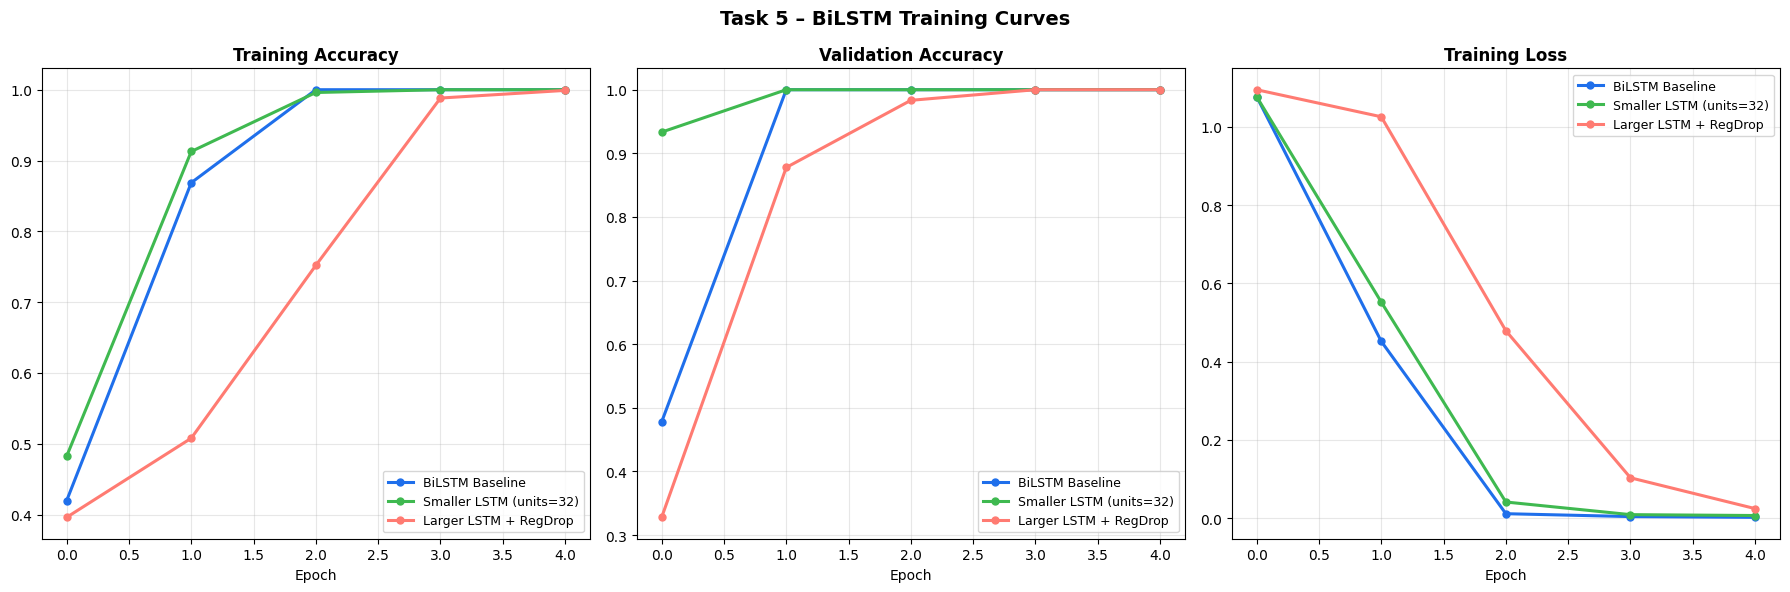

In [22]:
#Visualise Training Curves
COLORS = ['#1F6FEB','#3FB950','#FF7B72']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Task 5 – BiLSTM Training Curves', fontsize=14, fontweight='bold')

for (metric, title), ax in zip([
        ('accuracy',    'Training Accuracy'),
        ('val_accuracy','Validation Accuracy'),
        ('loss',        'Training Loss')], axes):
    for (label, hist), color in zip(exp_hists.items(), COLORS):
        ax.plot(hist[metric], color=color, lw=2.2, marker='o', ms=5, label=label)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/lstm_training_curves.png', dpi=130, bbox_inches='tight')
plt.show()


In [23]:
#Full comparison: ML vs LSTM
all_rows = (
    [{'Type':'Classical ML', 'Model':f"[{r['Vectorizer']}] {r['Model']}",
      'Test Acc': r['Accuracy'], 'Macro F1': r['Macro F1']} for r in ml_results] +
    [{'Type':'Deep Learning','Model': r['Model'],
      'Test Acc': r['Test Acc'],'Macro F1': r['Macro F1']} for r in exp_results]
)
df_all = pd.DataFrame(all_rows)
print("\n=== FULL MODEL COMPARISON ===")
print(df_all.to_string(index=False))
df_all.to_csv('results/model_comparison_table.csv', index=False)


=== FULL MODEL COMPARISON ===
         Type                        Model  Test Acc  Macro F1
 Classical ML    [BoW] Logistic Regression    1.0000    1.0000
 Classical ML            [BoW] Naive Bayes    1.0000    1.0000
 Classical ML             [BoW] Linear SVM    1.0000    1.0000
 Classical ML [TF-IDF] Logistic Regression    1.0000    1.0000
 Classical ML         [TF-IDF] Naive Bayes    1.0000    1.0000
 Classical ML          [TF-IDF] Linear SVM    1.0000    1.0000
Deep Learning              BiLSTM Baseline    0.4833    0.3903
Deep Learning      Smaller LSTM (units=32)    0.9233    0.9217
Deep Learning        Larger LSTM + RegDrop    0.3500    0.1728
